# Coupling Methods

In flow matching, a **coupling** decides which source point gets paired with which target point inside each batch.

This notebook covers two coupling strategies:

| Coupling | Strategy | Cost |
|---|---|---|
| `independent_coupling` | Uniform random pairing | O(N) |
| `ot_linear_coupling` | Minimise total transport cost (Sinkhorn) | O(N² log N) |

All return the same: `(src_idx, tgt_idx)` — index arrays used to reorder the batch before the training step.

> To see how the choice of coupling affects the **learned trajectories** after training, see [510\_coupling\_training.ipynb](510_coupling_training.ipynb).

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sc_flow.backends.torch.coupling import independent_coupling, ot_linear_coupling
from sc_flow.dataset.toy_data import get_toy_dataset

## Data

We load two datasets:

- **`moon_all`** — Target
- **`gauss_clusters`** — Source

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

# ── Moons (target) ────────────────────────────────────────────────────────────
adata = get_toy_dataset("moons", n_samples=1000, noise=0.05, random_state=42).adata
moon_all = torch.tensor(np.array(adata.X, dtype=np.float32))

# ── Gaussian clusters (source) ────────────────────────────────────────────────
n_clusters = 8
ring_radius = 2.5
moon_center = np.array([0.5, 0.05])
angles = np.linspace(0, 2 * np.pi, n_clusters, endpoint=False)
centers = moon_center + ring_radius * np.column_stack([np.cos(angles), np.sin(angles)])
gauss_clusters = torch.tensor(np.vstack([np.random.randn(60, 2) * 0.18 + c for c in centers]).astype(np.float32))

# ── Small batch for coupling plots ────────────────────────────────────────────
N = 100
src = gauss_clusters[torch.randperm(len(gauss_clusters))[:N]]  # source
tgt = moon_all[torch.randperm(len(moon_all))[:N]]  # target

print(f"gauss_clusters : {gauss_clusters.shape}  (source)")
print(f"moon_all       : {moon_all.shape}  (target)")


def plot_pairs(ax, src, tgt, src_idx, tgt_idx, title, color="gray", alpha=0.6):
    """Function for plotting"""
    for i in range(len(src_idx)):
        s = src[src_idx[i]].numpy()
        t = tgt[tgt_idx[i]].numpy()
        ax.plot([s[0], t[0]], [s[1], t[1]], lw=0.9, alpha=alpha, color=color)
    ax.scatter(moon_all[:, 0], moon_all[:, 1], s=6, color="steelblue", alpha=0.3, zorder=1, label="Moons")
    ax.scatter(
        gauss_clusters[:, 0], gauss_clusters[:, 1], s=6, color="dimgray", alpha=0.3, zorder=2, label="Gauss clusters"
    )
    # ax.scatter(src[:, 0], src[:, 1], s=50, color="dimgray", zorder=4, edgecolors="k", linewidths=0.4, label="src batch")
    # ax.scatter(tgt[:, 0], tgt[:, 1], s=50, color="mediumseagreen", zorder=5, label="tgt batch")
    ax.set_title(title, fontsize=11, family="monospace")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

gauss_clusters : torch.Size([480, 2])  (source)
moon_all       : torch.Size([1000, 2])  (target)


---
## 1. Independent Coupling

Two independent random permutations are drawn and paired by position — no matrix is computed, no geometry is used. Every (source, target) pair has equal probability 1/N².

**API:**

```python
src_idx, tgt_idx = independent_coupling(
    source,                  # (N, D)
    target,                  # (M, D)
)
```

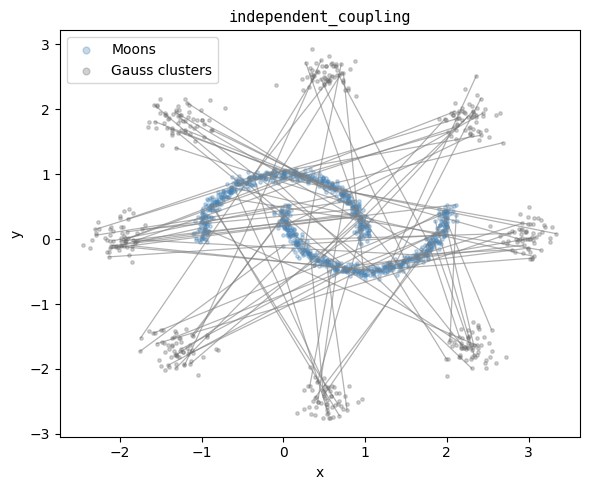

In [3]:
torch.manual_seed(1)

src_idx, tgt_idx = independent_coupling(src, tgt)

fig, ax = plt.subplots(figsize=(6, 5))
plot_pairs(ax, src, tgt, src_idx, tgt_idx, title="independent_coupling")
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

---
## 2. OT Linear Coupling

OT linear coupling solves an optimal transport problem: find a plan T (an N×M matrix) that minimises the total cost of moving mass from source to target, where cost defaults to squared Euclidean distance. T[i,j] represents how much probability mass flows from source i to target j. 

**API:**

```python
src_idx, tgt_idx = ot_linear_coupling(
    source,                  # (N, D)
    target,                  # (M, D)
    method="sinkhorn",       # "exact" | "sinkhorn" | "partial" | "unbalanced"
    reg=0.5,                 # entropic regularisation 
    reg_m=1.0,               # marginal relaxation (unbalanced only)
    scale_cost="mean",       # normalise cost matrix before solving
    return_matrix=False,     # if True, also return the N×M coupling matrix T
)
```

| `method` | Effect |
|---|---|
| `"exact"` | Earth mover's distance |
| `"sinkhorn"` | Entropic regularisation (default) |
| `"partial"` | |
| `"unbalanced"` | Relaxed marginals |

src_idx shape : (100,)
tgt_idx shape : (100,)
coupling matrix: (100, 100)


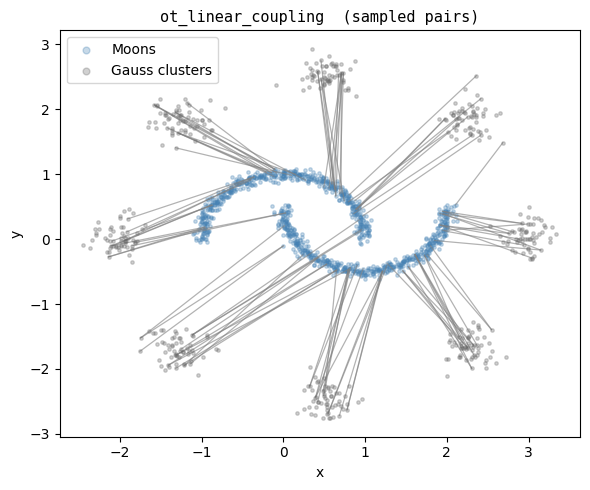

In [4]:
# Basic usage — returns index arrays directly
src_idx, tgt_idx = ot_linear_coupling(src, tgt)

# With return_matrix=True — also get the full N×M coupling matrix
src_idx, tgt_idx, tmat = ot_linear_coupling(src, tgt, return_matrix=True, reg=0.01)

print(f"src_idx shape : {src_idx.shape}")
print(f"tgt_idx shape : {tgt_idx.shape}")
print(f"coupling matrix: {tmat.shape}")

fig, ax = plt.subplots(figsize=(6, 5))
plot_pairs(ax, src, tgt, src_idx, tgt_idx, title="ot_linear_coupling  (sampled pairs)")
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

### Effect of `reg`

`reg` controls the entropy of the transport plan. A low `reg` produces a sharp, near-deterministic plan. A high `reg` produces a diffuse plan — each source spreads its mass across many targets.

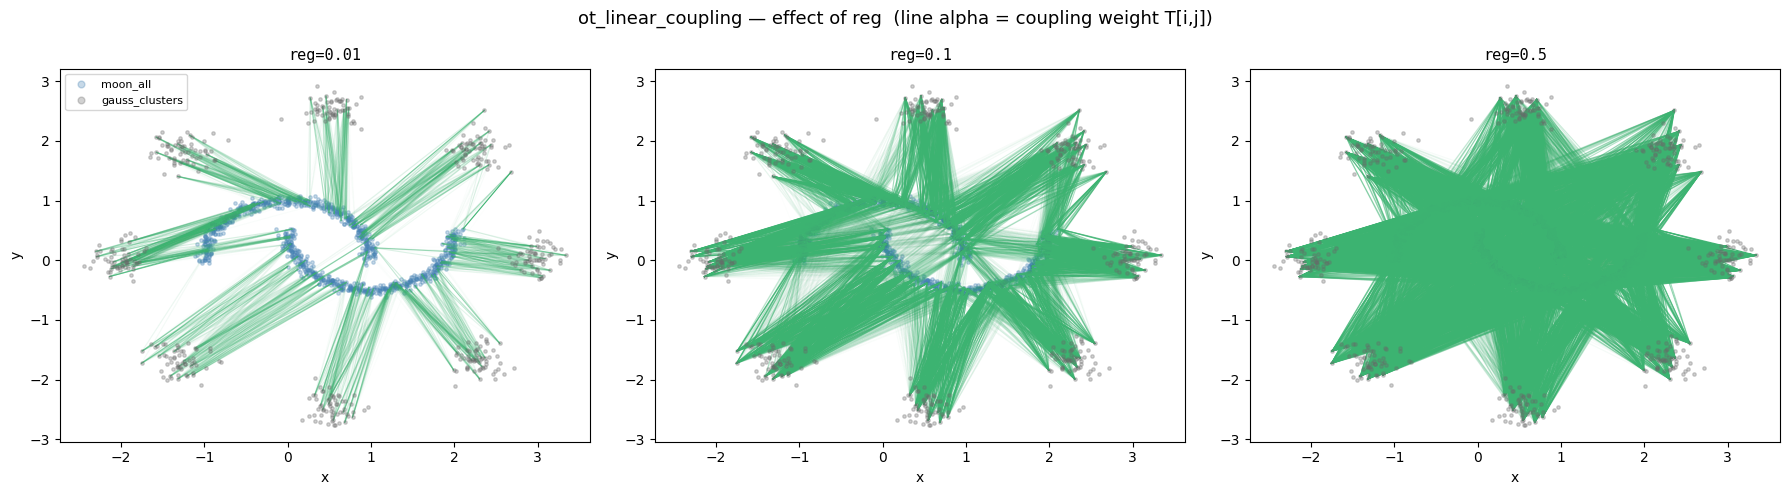

In [8]:
regs = [0.01, 0.1, 0.5]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, reg in zip(axes, regs, strict=False):
    _, _, tmat = ot_linear_coupling(src, tgt, return_matrix=True, reg=reg)
    tmat_norm = tmat / tmat.max()

    for i in range(tmat_norm.shape[0]):
        for j in range(tmat_norm.shape[1]):
            alpha = float(tmat_norm[i, j])
            if alpha < 0.01:
                continue
            s = src[i].numpy()
            t = tgt[j].numpy()
            ax.plot([s[0], t[0]], [s[1], t[1]], lw=0.8, alpha=alpha, color="mediumseagreen")

    ax.scatter(moon_all[:, 0], moon_all[:, 1], s=6, color="steelblue", alpha=0.3, zorder=1, label="moon_all")
    ax.scatter(
        gauss_clusters[:, 0], gauss_clusters[:, 1], s=6, color="dimgray", alpha=0.3, zorder=2, label="gauss_clusters"
    )
    # ax.scatter(src[:, 0], src[:, 1], s=50, color="dimgray", zorder=4, edgecolors="k", linewidths=0.4, label="src batch")
    # ax.scatter(tgt[:, 0], tgt[:, 1], s=50, color="mediumseagreen", zorder=5, label="tgt batch")
    ax.set_title(f"reg={reg}", fontsize=11, family="monospace")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

axes[0].legend(markerscale=2, fontsize=8)
plt.suptitle("ot_linear_coupling — effect of reg  (line alpha = coupling weight T[i,j])", fontsize=13)
plt.tight_layout()
plt.show()

### Effect of `method`

The `method` parameter selects the OT solver:

- **`"exact"`** — Earth Mover's Distance. No regularisation. Expensive on large batches.
- **`"sinkhorn"`** — Entropic regularisation (default). Plan regularized by `reg`. Faster and more stable.
- **`"partial"`** — Only a fraction `m` of total mass is transported.
- **`"unbalanced"`** — Marginals are relaxed by `reg_m`. Every source still participates, but points far from a match contribute less weight.

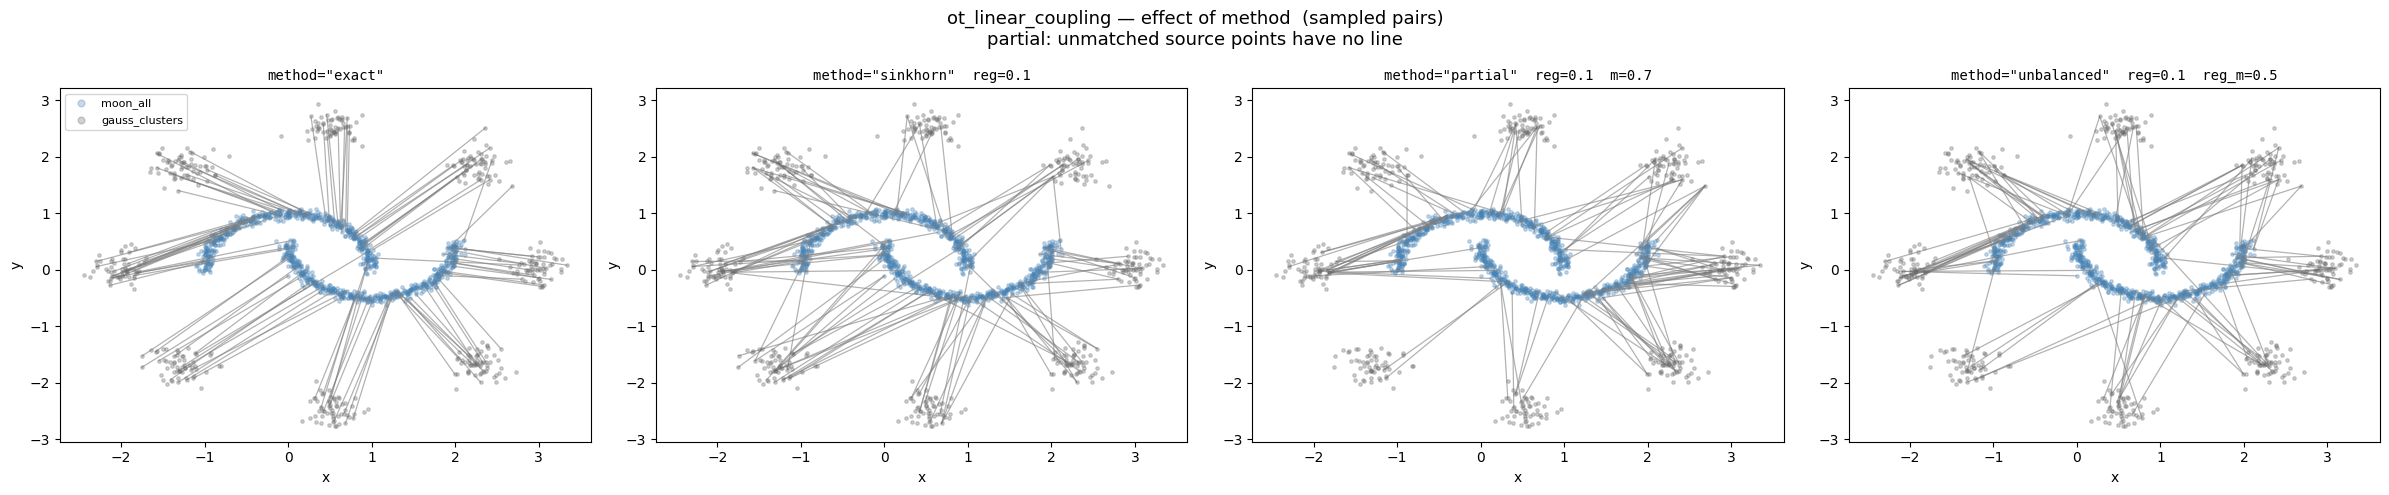

In [14]:
configs = [
    ("exact", {}),
    ("sinkhorn", {"reg": 0.1}),
    ("partial", {"reg": 0.1, "m": 0.7}),
    ("unbalanced", {"reg": 0.1, "reg_m": 0.5}),
]

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, (method, kw) in zip(axes, configs, strict=False):
    src_idx, tgt_idx = ot_linear_coupling(src, tgt, method=method, **kw)

    for i in range(len(src_idx)):
        s = src[src_idx[i]].numpy()
        t = tgt[tgt_idx[i]].numpy()
        ax.plot([s[0], t[0]], [s[1], t[1]], lw=0.9, alpha=0.6, color="gray")

    ax.scatter(moon_all[:, 0], moon_all[:, 1], s=6, color="steelblue", alpha=0.3, zorder=1, label="moon_all")
    ax.scatter(
        gauss_clusters[:, 0], gauss_clusters[:, 1], s=6, color="dimgray", alpha=0.3, zorder=2, label="gauss_clusters"
    )
    # ax.scatter(src[:, 0], src[:, 1], s=50, color="dimgray",        zorder=4, edgecolors="k", linewidths=0.4, label="src batch")
    # ax.scatter(tgt[:, 0], tgt[:, 1], s=50, color="mediumseagreen", zorder=5, label="tgt batch")
    subtitle = f'method="{method}"'
    if kw:
        subtitle += "  " + "  ".join(f"{k}={v}" for k, v in kw.items())
    ax.set_title(subtitle, fontsize=10, family="monospace")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

axes[0].legend(markerscale=2, fontsize=8)
plt.suptitle(
    "ot_linear_coupling — effect of method  (sampled pairs)\npartial: unmatched source points have no line",
    fontsize=13,
)
plt.tight_layout()
plt.show()